<a href="https://colab.research.google.com/github/Keerthi291890/Signal-Classification-Using-deep-learning/blob/main/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Run this at the top of the notebook (Colab usually has these but this ensures availability)
!pip install -q scikit-learn scipy librosa


In [ ]:
ZIP_PATH = "/content/Dataset_sdcs.zip"
import zipfile, os, glob

EXTRACT_DIR = "/content/rtl_sdr_data"   # change if you want
os.makedirs(EXTRACT_DIR, exist_ok=True)

if ZIP_PATH is None:
    raise RuntimeError("ZIP_PATH is not set. Upload the zip (Cell 2) or set ZIP_PATH from Drive (Cell 1).")

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)

# Find CSV files under the extracted folder
csv_files = glob.glob(os.path.join(EXTRACT_DIR, "**", "*.csv"), recursive=True)
print(f"Found {len(csv_files)} CSV files. Showing first 20:")
for f in csv_files[:20]:
    print(" -", f)
import pandas as pd
sample = csv_files[0]
print("Sample file:", sample)
df = pd.read_csv(sample, nrows=5)
print("Columns:", len(df.columns))
print(df.head().T)  # transpose to view columns vertically
import re
from tqdm import tqdm

# Function to infer label from filename: adjust regex if needed
def label_from_filename(path):
    # common patterns you showed: "fm1 (1)_FM_Broadcast_Radio.csv"
    name = os.path.basename(path)
    # remove extension then try to get part after underscore
    base = os.path.splitext(name)[0]
    if "_" in base:
        return base.split("_", 1)[1]
    # fallback: try words like "FM", "AM", "Airband" in name
    m = re.search(r"(FM|AM|Airband|GSM|WIFI|LTE|RADIO|Broadcast)", name, re.IGNORECASE)
    return m.group(1) if m else base

# Read and concat
dfs = []
for f in tqdm(csv_files):
    # read whole file; if too big, consider reading chunks or selected columns
    _df = pd.read_csv(f)
    if 'label' not in _df.columns:
        _df['label'] = label_from_filename(f)
    else:
        # ensure label is consistent
        _df['label'] = _df['label'].astype(str)
    dfs.append(_df)

full_df = pd.concat(dfs, ignore_index=True)
print("Combined dataframe shape:", full_df.shape)
print("Labels distribution:")
print(full_df['label'].value_counts())
# Identify typical raw columns (I_0, Q_0, I_1, etc.). Adjust if your naming differs.
cols = full_df.columns.tolist()

# Heuristics: raw IQ columns often start with I_ or Q_ or sample_ . Statistical features include 'Amp_' or 'Power_'.
raw_cols = [c for c in cols if re.match(r'^[IQiq]_\d+', c) or re.match(r'^[iIqQ]_\d+', c)]
stat_cols = [c for c in cols if (c not in raw_cols) and (c != 'label')]

print(f"Detected {len(raw_cols)} raw columns, {len(stat_cols)} statistical/other columns.")
print("First 10 raw columns:", raw_cols[:10])
print("First 20 stat columns:", stat_cols[:20])


Found 8 CSV files. Showing first 20:
 - /content/rtl_sdr_data/Dataset_sdcs/fm2 (1)_FM_Broadcast_Radio.csv
 - /content/rtl_sdr_data/Dataset_sdcs/ab1 (1)_Airband.csv
 - /content/rtl_sdr_data/Dataset_sdcs/fm3 (1)_FM_Broadcast_Radio.csv
 - /content/rtl_sdr_data/Dataset_sdcs/am3 (1)_AM_Broadcast_Radio.csv
 - /content/rtl_sdr_data/Dataset_sdcs/am2 (1)_AM_Broadcast_Radio.csv
 - /content/rtl_sdr_data/Dataset_sdcs/fm1 (1)_FM_Broadcast_Radio.csv
 - /content/rtl_sdr_data/Dataset_sdcs/am1 (1)_AM_Broadcast_Radio.csv
 - /content/rtl_sdr_data/Dataset_sdcs/ab2 (1)_Airband.csv
Sample file: /content/rtl_sdr_data/Dataset_sdcs/fm2 (1)_FM_Broadcast_Radio.csv
Columns: 17430
                                    0                   1                   2  \
I_0                          0.000002            0.006094           -0.013845   
I_1                              -0.0           -0.000078           -0.015179   
I_2                          0.000001           -0.003369           -0.012951   
I_3            

100%|██████████| 8/8 [00:21<00:00,  2.71s/it]


Combined dataframe shape: (705, 17430)
Labels distribution:
label
AM_Broadcast_Radio    274
FM_Broadcast_Radio    270
Airband               161
Name: count, dtype: int64
Detected 4096 raw columns, 13333 statistical/other columns.
First 10 raw columns: ['I_0', 'I_1', 'I_2', 'I_3', 'I_4', 'I_5', 'I_6', 'I_7', 'I_8', 'I_9']
First 20 stat columns: ['Amp_0', 'Amp_1', 'Amp_2', 'Amp_3', 'Amp_4', 'Amp_5', 'Amp_6', 'Amp_7', 'Amp_8', 'Amp_9', 'Amp_10', 'Amp_11', 'Amp_12', 'Amp_13', 'Amp_14', 'Amp_15', 'Amp_16', 'Amp_17', 'Amp_18', 'Amp_19']


X shape before PCA: (705, 4096)
X_pca shape: (705, 136)


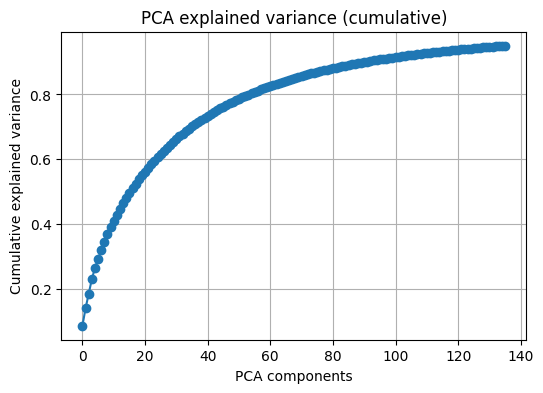

PCA resulted in 136 components (target variance=0.95)
Label classes: ['AM_Broadcast_Radio', 'Airband', 'FM_Broadcast_Radio']
y shape: (705,)
Final df shape: (705, 138)
Built 200 spectrograms; example shape: (65, 63)
Class Weights: {0: np.float64(0.8584474885844748), 1: np.float64(1.4573643410852712), 2: np.float64(0.8703703703703703)}
Train/Test shapes: (564, 136) (141, 136) (564,) (141,)
Saved processed files to: /content/processed_dataset

🔝 Top 15 Most Correlated Features with Signal Label:
Amp_skew           0.772393
FFT_427            0.734074
Amp_std            0.719025
Q_std              0.698956
I_std              0.698879
RMS_amp            0.686297
Amp_peak_to_RMS    0.667953
FFT_295            0.667383
Amp_mean           0.666878
FFT_426            0.657628
FFT_151            0.653937
FFT_161            0.653294
FFT_294            0.646557
FFT_302            0.644371
FFT_301            0.644016
Name: label_encoded, dtype: float64


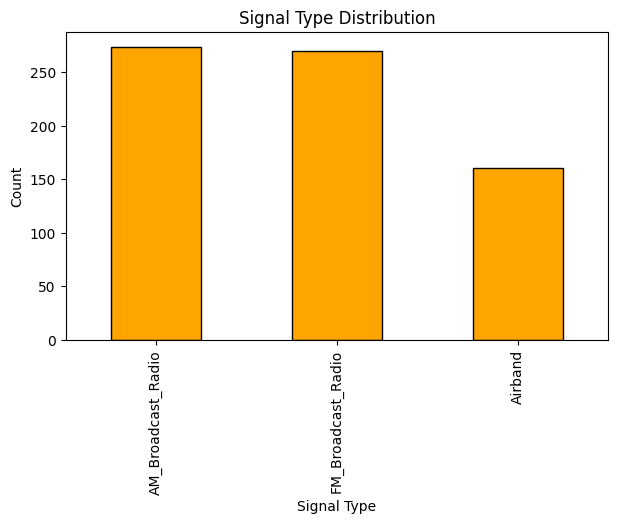

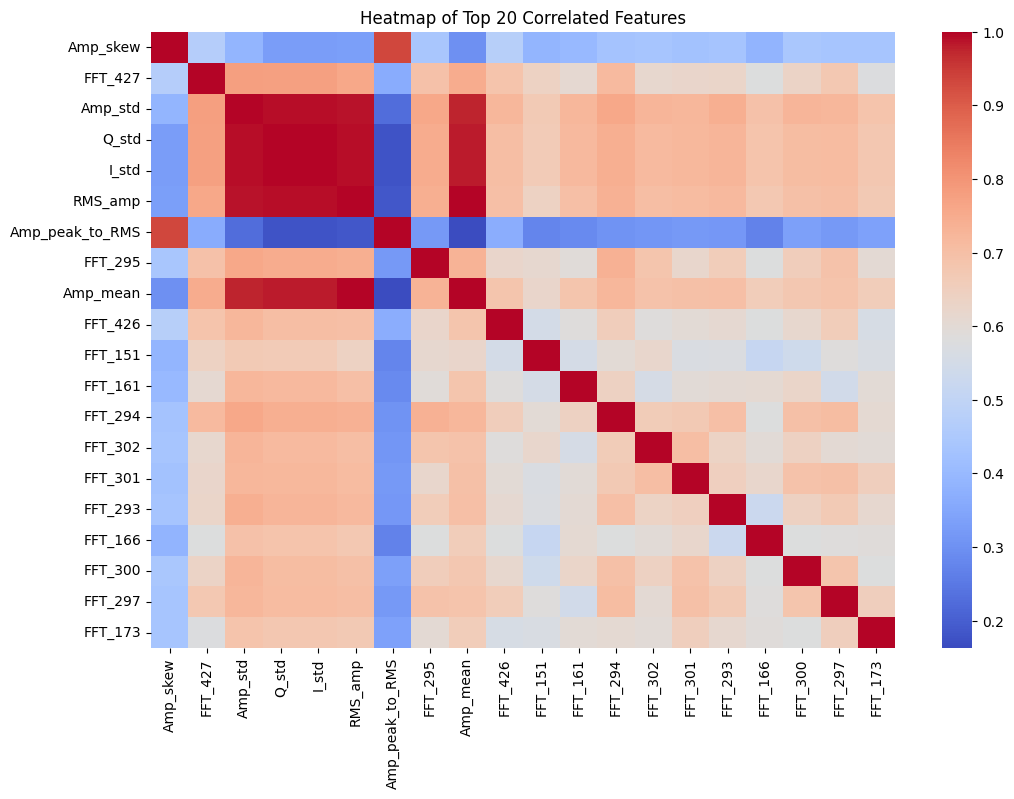

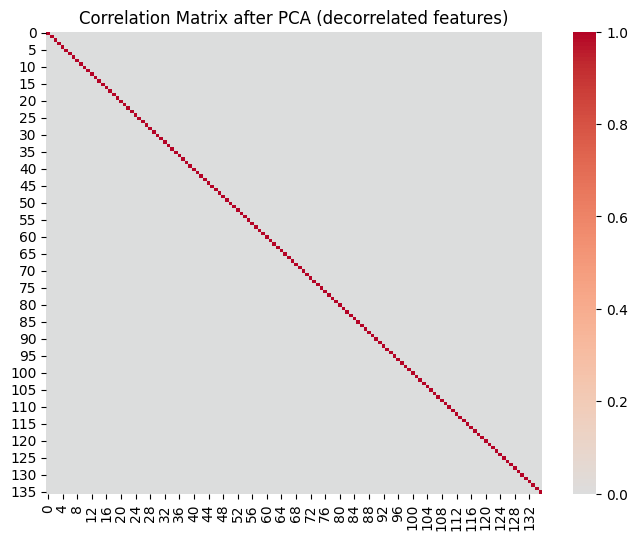

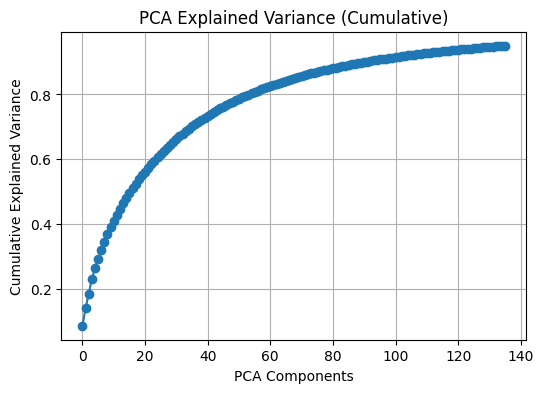

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Drop rows with all-NaNs (rare)
full_df.dropna(how='all', inplace=True)

# For stat features: impute then scale
stat_df = full_df[stat_cols].copy()
stat_imputer = SimpleImputer(strategy='mean')
stat_df_imputed = pd.DataFrame(stat_imputer.fit_transform(stat_df), columns=stat_df.columns)

scaler_stat = StandardScaler()
stat_scaled = scaler_stat.fit_transform(stat_df_imputed)  # numpy array

# For raw columns: impute/scale
raw_df = full_df[raw_cols].copy()
if raw_df.shape[1] == 0:
    print("No raw IQ columns detected. You may use statistical features or create spectrograms.")
else:
    raw_imputer = SimpleImputer(strategy='mean')
    raw_imputed = pd.DataFrame(raw_imputer.fit_transform(raw_df), columns=raw_df.columns)
    scaler_raw = StandardScaler()
    raw_scaled = scaler_raw.fit_transform(raw_imputed)
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Choose the data to PCA: stat_scaled OR raw_scaled
# For MLP baseline we typically use stat_scaled (small)
# For dimensionality reduction of raw high-dim data use raw_scaled.
DATA_FOR_PCA = 'raw'   # options: 'raw' or 'stat'

PCA_KEEP_VARIANCE = 0.95   # keep 95% variance; change to desired float
PCA_N_COMPONENTS = None    # Or set integer directly, e.g. 300

if DATA_FOR_PCA == 'raw':
    X = raw_scaled
else:
    X = stat_scaled

print("X shape before PCA:", X.shape)

if PCA_N_COMPONENTS is not None:
    pca = PCA(n_components=PCA_N_COMPONENTS, svd_solver='randomized', whiten=False)
else:
    pca = PCA(n_components=PCA_KEEP_VARIANCE, svd_solver='auto', whiten=False)

X_pca = pca.fit_transform(X)
print("X_pca shape:", X_pca.shape)

# show explained variance curve
plt.figure(figsize=(6,4))
explained = np.cumsum(pca.explained_variance_ratio_)
plt.plot(explained, marker='o')
plt.xlabel("PCA components")
plt.ylabel("Cumulative explained variance")
plt.grid(True)
plt.title("PCA explained variance (cumulative)")
plt.show()

# Optionally print how many components were chosen
n_comp = X_pca.shape[1]
print(f"PCA resulted in {n_comp} components (target variance={PCA_KEEP_VARIANCE})")
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
labels = full_df['label'].astype(str).values
le = LabelEncoder()
y = le.fit_transform(labels)
print("Label classes:", list(le.classes_))
print("y shape:", y.shape)

# Make final DataFrame for saving (optional)
import pandas as pd
pca_cols = [f"PC_{i}" for i in range(X_pca.shape[1])]
df_final = pd.DataFrame(X_pca, columns=pca_cols)
df_final['label'] = labels
df_final['label_encoded'] = y
print("Final df shape:", df_final.shape)
df_final.head()
# If you want 2D inputs (spectrograms) for CNN: create spectrograms from raw IQ or magnitude.
# We'll demonstrate using raw I columns only (if Q present, combine them into complex)
import numpy as np
from scipy.signal import spectrogram

def make_spectrogram_from_sample(i_row, fs=1.0, nperseg=256, noverlap=128):
    # i_row: 1D numpy array (I samples) OR interleaved [I0,Q0,I1,Q1,...]
    # If Q is present as pairs, user must adapt this function.
    f, t, Sxx = spectrogram(i_row, fs=fs, nperseg=nperseg, noverlap=noverlap, mode='magnitude')
    return Sxx  # shape: (freq_bins, time_bins)

# Example: build spectrograms for the first N samples (be careful with memory)
N = 200  # reduce if memory is limited
if raw_scaled.shape[0] >= 1:
    spec_list = []
    for i in range(min(N, raw_scaled.shape[0])):
        sample = raw_scaled[i, :]  # 1D
        # optionally convert to magnitude if interleaved IQ; here we assume it's sequence of real samples
        S = make_spectrogram_from_sample(sample, fs=1.0, nperseg=128, noverlap=64)
        spec_list.append(S)
    print("Built", len(spec_list), "spectrograms; example shape:", spec_list[0].shape)
else:
    print("No raw samples found to build spectrograms.")
from sklearn.model_selection import train_test_split
import numpy as np

# Choose features to use for training:
# Option A: use PCA features (df_final[pca_cols].values)
# Option B: use stat_scaled
# Option C: use raw (not recommended without heavy reduction)
X_final = df_final[pca_cols].values  # PCA output
y_final = df_final['label_encoded'].values

# Split
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, stratify=y)


# Compute class weights automatically
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights)
print("Train/Test shapes:", X_train.shape, X_test.shape, y_train.shape, y_test.shape)

# Save .npy files
out_dir = "/content/processed_dataset"
os.makedirs(out_dir, exist_ok=True)
np.save(os.path.join(out_dir, "X_train_pca.npy"), X_train)
np.save(os.path.join(out_dir, "X_test_pca.npy"), X_test)
np.save(os.path.join(out_dir, "y_train.npy"), y_train)
np.save(os.path.join(out_dir, "y_test.npy"), y_test)

# Save combined CSV for inspection
df_final.to_csv(os.path.join(out_dir, "final_pca_dataset.csv"), index=False)
print("Saved processed files to:", out_dir)
from google.colab import files
#files.download(os.path.join(out_dir, "final_pca_dataset.csv"))
# For large .npy files you may prefer to transfer to Drive:
# !cp -r /content/processed_dataset /content/drive/MyDrive/
# ================================================
# 🔹 CORRELATION & FEATURE IMPORTANCE INSIGHT
# ================================================
import seaborn as sns
import matplotlib.pyplot as plt

# Convert stat_df_imputed back to DataFrame (if not already)
stat_df_clean = pd.DataFrame(stat_scaled, columns=stat_cols)
stat_df_clean['label_encoded'] = y

# Compute correlation matrix
corr_matrix = stat_df_clean.corr()

# Extract correlation of features w.r.t. label
label_corr = corr_matrix['label_encoded'].drop('label_encoded').sort_values(ascending=False)

print("\n🔝 Top 15 Most Correlated Features with Signal Label:")
print(label_corr.head(15))

# Plot class distribution
plt.figure(figsize=(7, 4))
full_df['label'].value_counts().plot(kind='bar', color='orange', edgecolor='k')
plt.title("Signal Type Distribution")
plt.xlabel("Signal Type")
plt.ylabel("Count")
plt.show()

# Plot heatmap for top 20 correlated features
top_features = label_corr.head(20).index
plt.figure(figsize=(12, 8))
sns.heatmap(stat_df_clean[top_features].corr(), cmap='coolwarm', annot=False)
plt.title("Heatmap of Top 20 Correlated Features")
plt.show()

import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation for PCA components
corr_pca = np.corrcoef(X_pca.T)

plt.figure(figsize=(8,6))
sns.heatmap(corr_pca, cmap='coolwarm', center=0)
plt.title("Correlation Matrix after PCA (decorrelated features)")
plt.show()


# Optional: Visualize PCA variance explained
plt.figure(figsize=(6,4))
explained = np.cumsum(pca.explained_variance_ratio_)
plt.plot(explained, marker='o')
plt.xlabel("PCA Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.title("PCA Explained Variance (Cumulative)")
plt.show()



In [ ]:
###############  verification ##################
import pandas as pd
import numpy as np

# Assuming your label column is named 'label' and already label-encoded
# Use np.unique and np.bincount for value counts on numpy arrays
unique_train, counts_train = np.unique(y_train, return_counts=True)
print("Train label distribution:")
for label, count in zip(unique_train, counts_train):
    print(f"Label {label}: {count}")

unique_test, counts_test = np.unique(y_test, return_counts=True)
print("\nTest label distribution:")
for label, count in zip(unique_test, counts_test):
    print(f"Label {label}: {count}")

Train label distribution:
Label 0: 219
Label 1: 129
Label 2: 216

Test label distribution:
Label 0: 55
Label 1: 32
Label 2: 54


In [ ]:
# Run this cell if packages are missing in Colab
!pip install -q imbalanced-learn


Deterministic environment ready!
Loaded dataframe shape: (705, 138)
Label distribution:
 label
AM_Broadcast_Radio    274
FM_Broadcast_Radio    270
Airband               161
Name: count, dtype: int64


,PC_0,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,...,PC_128,PC_129,PC_130,PC_131,PC_132,PC_133,PC_134,PC_135,label,label_encoded
0,0.405441,-6.276696,-3.262286,0.232857,-1.361569,-0.882771,-0.591733,2.413224,-0.065435,0.436332,...,0.414586,-0.108926,0.074097,0.113818,-0.078320,0.412101,-0.795924,-0.014509,FM_Broadcast_Radio,2
1,-0.157133,-6.923977,-2.534660,-0.111401,-0.934808,-1.875053,-0.575248,1.059313,-0.785440,-1.259638,...,0.125778,-0.417602,0.218525,-0.376628,0.123350,-0.172872,0.115526,0.003527,FM_Broadcast_Radio,2
2,-1.972274,-6.151512,-1.868976,-1.208428,-0.002318,-1.761285,-1.205199,0.331119,1.055201,1.851394,...,0.549514,0.912464,-0.690972,-0.271434,0.435808,0.409335,-0.117563,-0.896312,FM_Broadcast_Radio,2
3,-0.681101,-6.940319,-2.227261,-0.417781,0.050535,-0.232297,-2.462399,1.213762,0.494338,0.515976,...,-1.524060,1.568554,-0.357811,-0.817437,-0.924196,2.141104,-0.588897,-0.830941,FM_Broadcast_Radio,2
4,-0.222177,-6.370887,-2.535645,-0.998821,-0.562641,-1.381405,-1.314332,0.606507,0.505783,0.603125,...,-0.189873,-1.075617,-0.356267,-0.772447,-1.382580,0.753187,-1.166238,-1.314164,FM_Broadcast_Radio,2


No 'group' or 'orig_file' → Creating heuristic groups
Number of PCA features: 136
Unique classes: ['AM_Broadcast_Radio' 'Airband' 'FM_Broadcast_Radio']
Train label distribution: [214 141 190]
Test label distribution: [60 20 80]
Augmented shape: (1090, 97)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 64)             │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,451 (33.01 KB)

 Trainable params: 8,451 (33.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3023 - loss: 1.7398 - val_accuracy: 0.4500 - val_loss: 1.0758
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4881 - loss: 1.1368 - val_accuracy: 0.7812 - val_loss: 0.9526
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6187 - loss: 0.9700 - val_accuracy: 0.9438 - val_loss: 0.8613
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7261 - loss: 0.8611 - val_accuracy: 0.9812 - val_loss: 0.7801
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8138 - loss: 0.7598 - val_accuracy: 0.9875 - val_loss: 0.7122
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8834 - loss: 0.6459 - val_accuracy: 0.9750 - val_loss: 0.6424
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9018 - loss: 0.5958 - val_accuracy: 0.9688 - val_loss: 0.5837
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9236 - loss: 0.5284 - val_accuracy: 0.9563 - 

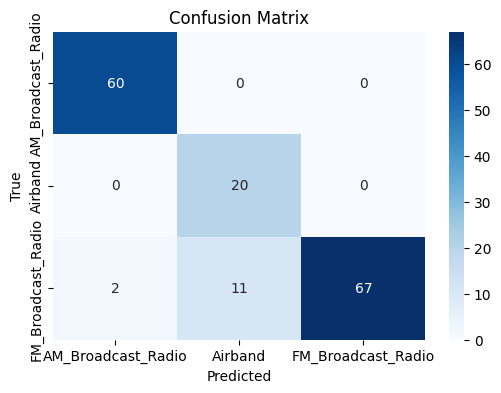

Saved model + scaler + PCA.


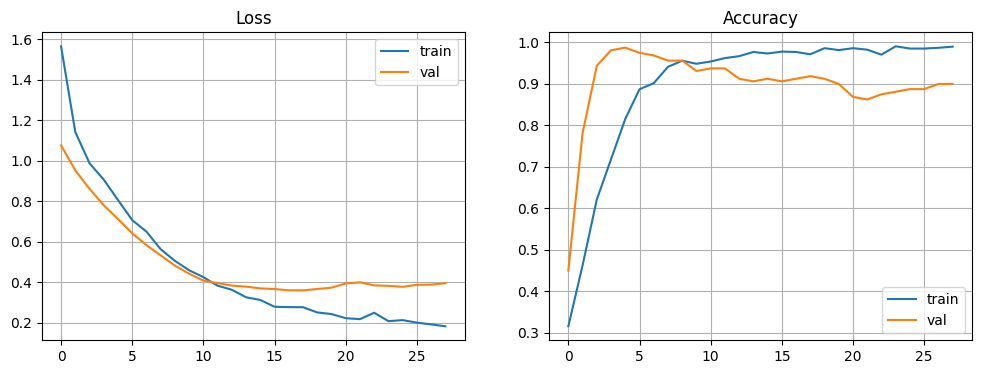

In [ ]:
# ============================================
# 🔒 FULLY DETERMINISTIC SETUP (VERY IMPORTANT)
# ============================================
import os
import random
import numpy as np
import tensorflow as tf

SEED = 42

# Disable GPU to avoid cuDNN nondeterminism
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

# Disable parallelism for reproducibility
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["TF_NUM_INTRAOP_THREADS"] = "1"
os.environ["TF_NUM_INTEROP_THREADS"] = "1"

# Fix all random seeds
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Force deterministic TF ops
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

# ============================================
# 📌 IMPORTS
# ============================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping

# ============================================
# 📌 PATHS
# ============================================
DATA_CSV = "/content/processed_dataset/final_pca_dataset.csv"
OUT_DIR = "/content/processed_dataset"
os.makedirs(OUT_DIR, exist_ok=True)

print("Deterministic environment ready!")

# ============================================
# 📌 LOAD DATA
# ============================================
df = pd.read_csv(DATA_CSV)
print("Loaded dataframe shape:", df.shape)
print("Label distribution:\n", df['label'].value_counts())
display(df.head())

# ============================================
# 📌 GROUP HANDLING
# ============================================
if 'group' in df.columns:
    print("Using existing 'group' column.")
elif 'orig_file' in df.columns:
    df['group'] = df['orig_file']
    print("Using 'orig_file' as group.")
else:
    print("No 'group' or 'orig_file' → Creating heuristic groups")
    chunk_size = 20
    df['group'] = df.groupby('label').cumcount() // chunk_size
    df['group'] = df['label'].astype(str) + "_" + df['group'].astype(str)

# ============================================
# 📌 FEATURE SELECTION
# ============================================
feature_cols = [c for c in df.columns if c.startswith("PC_")]

print("Number of PCA features:", len(feature_cols))

# ============================================
# 📌 LABEL ENCODING
# ============================================
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

# ============================================
# 📌 CORRELATION CHECK
# ============================================
corrs = df[feature_cols].corrwith(df['label_encoded']).abs().sort_values(ascending=False)
to_drop = corrs[corrs > 0.95].index.tolist()
feature_cols = [c for c in feature_cols if c not in to_drop]

# ============================================
# 📌 EXTRACT INPUTS
# ============================================
X = df[feature_cols].values
y = df['label_encoded'].values
groups = df['group'].values

print("Unique classes:", le.classes_)

# ============================================
# 📌 GROUPED TRAIN/TEST SPLIT
# ============================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train_raw, X_test_raw = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("Train label distribution:", np.bincount(y_train))
print("Test label distribution:", np.bincount(y_test))

# ============================================
# 📌 SCALER (DETERMINISTIC)
# ============================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# ============================================
# 📌 PCA (DETERMINISTIC)
# ============================================
pca = PCA(n_components=0.95, svd_solver="auto", random_state=SEED)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# ============================================
# 📌 DETERMINISTIC NOISE AUGMENTATION
# ============================================
def deterministic_augment(X, y, sigma=0.02, times=1, seed=SEED):
    if times <= 0:
        return X, y
    rng = np.random.default_rng(seed)
    Xs = [X]
    ys = [y]
    for i in range(times):
        noise = rng.normal(0, sigma, X.shape)
        Xs.append(X + noise)
        ys.append(y.copy())
    return np.vstack(Xs), np.concatenate(ys)

X_train_aug, y_train_aug = deterministic_augment(X_train_pca, y_train, sigma=0.02, times=1)

print("Augmented shape:", X_train_aug.shape)

# ============================================
# 📌 CLASS WEIGHTS
# ============================================
class_weights_vals = compute_class_weight(
    "balanced",
    classes=np.unique(y_train_aug),
    y=y_train_aug
)
class_weights = dict(enumerate(class_weights_vals))

# ============================================
# 📌 BUILD MLP MODEL (DETERMINISTIC)
# ============================================
n_features = X_train_aug.shape[1]
n_classes = len(le.classes_)

model = tf.keras.Sequential([
    tf.keras.Input(shape=(n_features,)),
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-3)),
    layers.Dropout(0.5),
    layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-3)),
    layers.Dropout(0.5),
    layers.Dense(n_classes, activation='softmax')
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ============================================
# 📌 TRAIN MODEL (NO RANDOM SHUFFLING!)
# ============================================
es = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_aug,
    y_train_aug,
    validation_data=(X_test_pca, y_test),
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    shuffle=False,         # IMPORTANT 🔥
    callbacks=[es],
    verbose=1
)

# ============================================
# 📌 EVALUATION
# ============================================
test_loss, test_acc = model.evaluate(X_test_pca, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}   Test accuracy: {test_acc:.4f}")

y_pred = np.argmax(model.predict(X_test_pca), axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# ============================================
# 📌 CONFUSION MATRIX
# ============================================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ============================================
# 📌 SAVE ARTIFACTS
# ============================================
import joblib

model.save(os.path.join(OUT_DIR, "mlp_deterministic.h5"))
joblib.dump(scaler, os.path.join(OUT_DIR, "scaler.joblib"))
joblib.dump(pca, os.path.join(OUT_DIR, "pca.joblib"))

print("Saved model + scaler + PCA.")

# ============================================
# 📌 TRAINING CURVES
# ============================================
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()
plt.grid(True)

plt.show()


Loaded dataframe shape: (705, 138)
No 'group' column found. Creating heuristic groups (change chunk_size if needed).
Unique groups: 37
Label counts:
 label
AM_Broadcast_Radio    274
FM_Broadcast_Radio    270
Airband               161
Name: count, dtype: int64
Train groups: 29 Test groups: 8
Train samples: 564 Test samples: 141
Train label counts: {'AM_Broadcast_Radio': 214, 'FM_Broadcast_Radio': 210, 'Airband': 140}
Test label counts: {'FM_Broadcast_Radio': 60, 'AM_Broadcast_Radio': 60, 'Airband': 21}
CNN input shape: (564, 136, 1)
Class weights: {0: 0.8785046728971962, 1: 1.3428571428571427, 2: 0.8952380952380953}


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 136, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 136, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 136, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 136, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 68, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 68, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 68, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 68, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 34, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 34, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 34, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 34, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,547 (174.01 KB)

 Trainable params: 44,099 (172.26 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/80

Epoch 1: val_loss improved from inf to 0.83997, saving model to /content/processed_dataset/cnn_improved/best_model.keras
18/18 - 12s - 676ms/step - accuracy: 0.6596 - loss: 0.7782 - val_accuracy: 0.8865 - val_loss: 0.8400 - learning_rate: 1.0000e-03
Epoch 2/80

Epoch 2: val_loss improved from 0.83997 to 0.68805, saving model to /content/processed_dataset/cnn_improved/best_model.keras
18/18 - 1s - 75ms/step - accuracy: 0.8369 - loss: 0.5570 - val_accuracy: 0.7660 - val_loss: 0.6881 - learning_rate: 1.0000e-03
Epoch 3/80

Epoch 3: val_loss improved from 0.68805 to 0.65234, saving model to /content/processed_dataset/cnn_improved/best_model.keras
18/18 - 2s - 120ms/step - accuracy: 0.8546 - loss: 0.4488 - val_accuracy: 0.6950 - val_loss: 0.6523 - learning_rate: 1.0000e-03
Epoch 4/80

Epoch 4: val_loss did not improve from 0.65234
18/18 - 1s - 43ms/step - accuracy: 0.8103 - loss: 0.5257 - val_accuracy: 0.6809 - val_loss: 0.7036 - learning_rate: 1.0000e-03
Epoch 5/80

Epoch 5: va

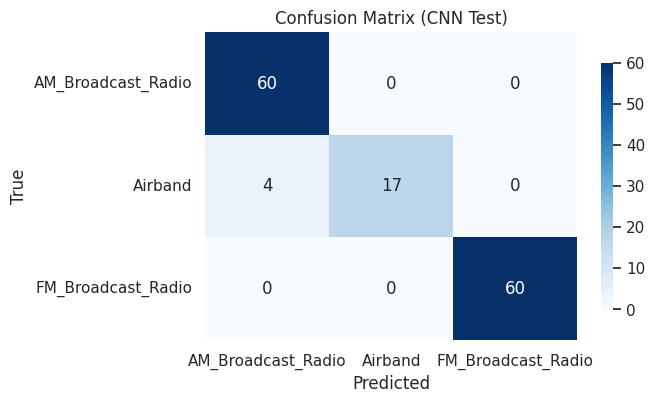

Saved scaler & group_map in /content/processed_dataset/cnn_improved


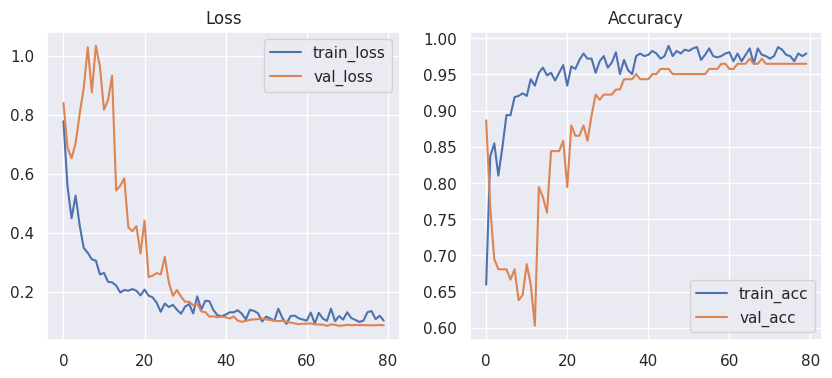

In [ ]:
# Colab-ready: Stratified grouped split + improved CNN (less overfitting)
# Run in one cell. Adjust DATA_CSV if you saved the preprocessed CSV elsewhere.

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedShuffleSplit
import tensorflow as tf
from tensorflow.keras import layers, regularizers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Set the random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Ensure deterministic behavior in TensorFlow by disabling certain non-deterministic operations
# These configurations are particularly relevant when running on GPUs
# Disabling GPU operations that may cause non-determinism:
tf.config.experimental.enable_op_determinism()

# ---------- USER: path to your processed PCA CSV ----------
DATA_CSV = "/content/processed_dataset/final_pca_dataset.csv"
OUT_DIR = "/content/processed_dataset/cnn_improved"
os.makedirs(OUT_DIR, exist_ok=True)

# ---------- Load dataframe ----------
df = pd.read_csv(DATA_CSV)
print("Loaded dataframe shape:", df.shape)
# expected: columns PC_0...PC_n, label, label_encoded, (optionally group)
# If there is no 'group' column, try to use an available 'orig_file' or recreate heuristic groups.
if 'group' not in df.columns:
    if 'orig_file' in df.columns:
        df['group'] = df['orig_file']
        print("Using orig_file as group.")
    else:
        # Heuristic: group by filename-like value in 'label' + contiguous blocks if original source not stored
        print("No 'group' column found. Creating heuristic groups (change chunk_size if needed).")
        chunk_size = 20
        df['group'] = df.groupby('label').cumcount() // chunk_size
        df['group'] = df['label'].astype(str) + "_" + df['group'].astype(str)

print("Unique groups:", df['group'].nunique())
print("Label counts:\n", df['label'].value_counts())

# ---------- Build stratified grouped split ----------
group_labels = df.groupby('group')['label'].agg(lambda s: s.value_counts().idxmax())
group_df = group_labels.reset_index().rename(columns={'label':'group_label'})

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_SEED)
groups = group_df['group'].values
group_y = group_df['group_label'].values
train_groups_idx, test_groups_idx = next(sss.split(groups, group_y))
train_groups = set(groups[train_groups_idx])
test_groups  = set(groups[test_groups_idx])

train_mask = df['group'].isin(train_groups)
test_mask  = df['group'].isin(test_groups)

train_df = df[train_mask].reset_index(drop=True)
test_df  = df[test_mask].reset_index(drop=True)
print("Train groups:", len(train_groups), "Test groups:", len(test_groups))
print("Train samples:", train_df.shape[0], "Test samples:", test_df.shape[0])
print("Train label counts:", train_df['label'].value_counts().to_dict())
print("Test label counts:", test_df['label'].value_counts().to_dict())

# ---------- Features & preprocessing ----------
feature_cols = [c for c in df.columns if c.startswith("PC_")]
X_train = train_df[feature_cols].values.astype(np.float32)
X_test  = test_df[feature_cols].values.astype(np.float32)
y_train = train_df['label_encoded'].values.astype(np.int32)
y_test  = test_df['label_encoded'].values.astype(np.int32)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

X_train_cnn = X_train[..., np.newaxis]
X_test_cnn  = X_test[..., np.newaxis]
print("CNN input shape:", X_train_cnn.shape)

classes = np.unique(y_train)
class_weights_vals = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = {int(c): float(w) for c,w in zip(classes, class_weights_vals)}
print("Class weights:", class_weights)

# ---------- Simple on-the-fly augmentation via tf.data ----------
def augment_noise(x, y, sigma=0.02):
    noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=sigma, dtype=x.dtype)
    return x + noise, y

BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((X_train_cnn, y_train))
train_ds = train_ds.shuffle(1024, seed=RANDOM_SEED)
train_ds = train_ds.map(lambda x,y: augment_noise(x,y, sigma=0.02), num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_test_cnn, y_test)).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# ---------- Build improved (smaller) Conv1D model ----------
timesteps = X_train_cnn.shape[1]
channels = X_train_cnn.shape[2]
n_classes = len(np.unique(y_train))

def build_cnn(input_shape=(timesteps, channels), n_classes=n_classes, l2_rate=1e-4, dropout_rate=0.4):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv1D(32, kernel_size=5, padding='same', activation=None, kernel_regularizer=regularizers.l2(l2_rate))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = layers.Conv1D(64, kernel_size=5, padding='same', activation=None, kernel_regularizer=regularizers.l2(l2_rate))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = layers.Conv1D(128, kernel_size=3, padding='same', activation=None, kernel_regularizer=regularizers.l2(l2_rate))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(l2_rate))(x)
    x = layers.Dropout(dropout_rate)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inp, out)
    return model

model = build_cnn(input_shape=(timesteps, channels))
model.summary()

# ---------- Compile ----------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
es = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
ckpt_path = os.path.join(OUT_DIR, "best_model.keras")
mc = ModelCheckpoint(ckpt_path, monitor='val_loss', save_best_only=True, save_weights_only=False, verbose=1)

# ---------- Train ----------
EPOCHS = 80
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[es, rlr, mc],
    class_weight=class_weights,
    verbose=2
)

# ---------- Evaluate ----------
print("\nEvaluating on test set:")
test_loss, test_acc = model.evaluate(val_ds, verbose=2)
print(f"Test Loss: {test_loss:.4f}  Test Acc: {test_acc:.4f}")

# Predictions & classification report
from sklearn.metrics import classification_report, confusion_matrix
y_pred_proba = model.predict(X_test_cnn, batch_size=BATCH_SIZE)
y_pred = np.argmax(y_pred_proba, axis=1)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=np.unique(df['label'])))

# Confusion Matrix with colored output
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(df['label']),
            yticklabels=np.unique(df['label']),
            cbar_kws={"shrink": .8})
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (CNN Test)")
plt.show()

# ---------- Save artifacts ----------
import joblib
joblib.dump(scaler, os.path.join(OUT_DIR, "scaler.joblib"))
pd.DataFrame({'group': group_df['group'], 'group_label': group_df['group_label']}).to_csv(os.path.join(OUT_DIR, "group_map.csv"), index=False)
print("Saved scaler & group_map in", OUT_DIR)

# ---------- Learning curves ----------
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(); plt.title("Loss"); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend(); plt.title("Accuracy"); plt.grid(True)
plt.show()


Dataset: (705, 136) Labels: [0 1 2]

Accuracy: 0.9432624113475178

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94        55
           1       1.00      0.81      0.90        32
           2       0.98      0.96      0.97        54

    accuracy                           0.94       141
   macro avg       0.96      0.93      0.94       141
weighted avg       0.95      0.94      0.94       141



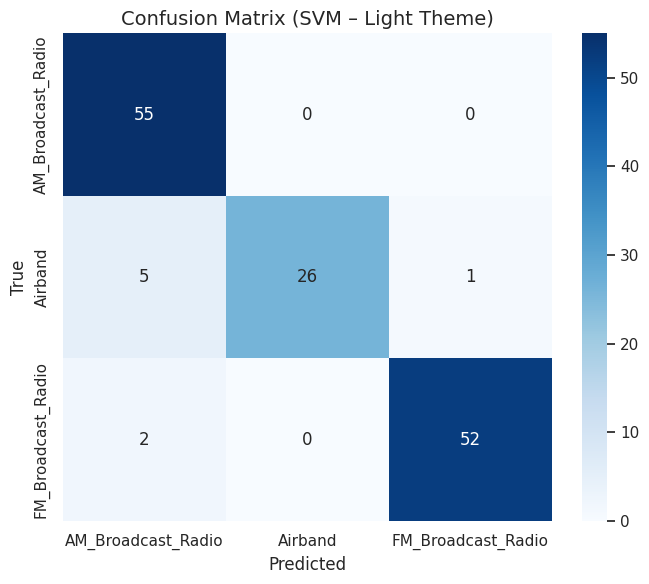

In [ ]:
# ------------------------------
# Imports SVM
# ------------------------------
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean, light theme
sns.set_theme(style="whitegrid")

# ------------------------------
# Load PCA dataset
# ------------------------------
df = pd.read_csv("/content/processed_dataset/final_pca_dataset.csv")

# Features (PC_0 ... PC_135)
X = df.filter(like="PC_").values

# Encoded labels
y = df["label_encoded"].values

print("Dataset:", X.shape, "Labels:", np.unique(y))

# ------------------------------
# Train/Test Split (Stratified)
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# ------------------------------
# SVM Pipeline
# ------------------------------
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=10, gamma="scale"))
])

# ------------------------------
# Train SVM
# ------------------------------
svm_model.fit(X_train, y_train)

# ------------------------------
# Predict
# ------------------------------
y_pred = svm_model.predict(X_test)

# ------------------------------
# Evaluation
# ------------------------------
print("\nAccuracy:", np.mean(y_pred == y_test))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ------------------------------
# Confusion Matrix (Light Colors, Clean Look)
# ------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("True", fontsize=12)
plt.title("Confusion Matrix (SVM – Light Theme)", fontsize=14)
plt.tight_layout()
plt.show()


Loaded dataframe shape: (705, 138)
Label distribution:
 label
AM_Broadcast_Radio    274
FM_Broadcast_Radio    270
Airband               161
Name: count, dtype: int64
Accuracy: 0.8298

Classification Report:
                    precision    recall  f1-score   support

FM_Broadcast_Radio       0.75      1.00      0.86        55
           Airband       0.83      0.91      0.87        32
AM_Broadcast_Radio       1.00      0.61      0.76        54

          accuracy                           0.83       141
         macro avg       0.86      0.84      0.83       141
      weighted avg       0.86      0.83      0.82       141



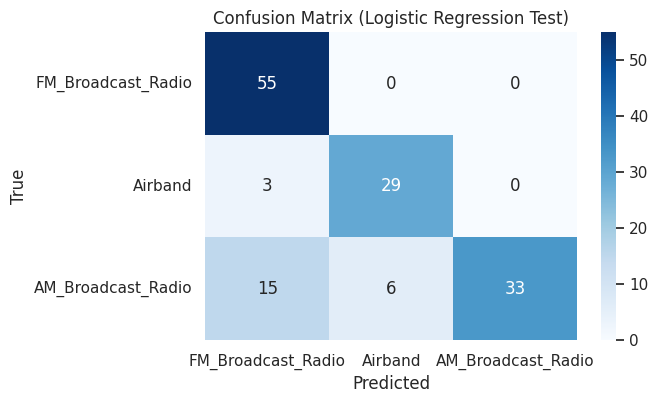

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ---------- USER: path to your processed PCA CSV ----------
DATA_CSV = "/content/processed_dataset/final_pca_dataset.csv"
OUT_DIR = "/content/processed_dataset/logistic_regression"
os.makedirs(OUT_DIR, exist_ok=True)

# ---------- Load dataframe ----------
df = pd.read_csv(DATA_CSV)
print("Loaded dataframe shape:", df.shape)
print("Label distribution:\n", df['label'].value_counts())

# ---------- Feature columns (PCA features) ----------
feature_cols = [c for c in df.columns if c.startswith("PC_")]
X = df[feature_cols].values.astype(np.float32)
y = df['label_encoded'].values.astype(np.int32)

# ---------- Stratified Split ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED
)

# ---------- Standardize features ----------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------- Logistic Regression Model ----------
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, class_weight='balanced')
logreg.fit(X_train_scaled, y_train)

# ---------- Predictions & Evaluation ----------
y_pred = logreg.predict(X_test_scaled)

# Accuracy
accuracy = np.mean(y_pred == y_test)
print(f"Accuracy: {accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=df['label'].unique()))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=df['label'].unique(),
            yticklabels=df['label'].unique())
plt.title("Confusion Matrix (Logistic Regression Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()



In [ ]:
# ========================================================
# 📌 FULL MODEL COMPARISON: LR • SVM • MLP • CNN
# ========================================================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --------------------------------------------------------
# ✔️ Add your models + predictions here
# (Replace variables with your actual ones)
# --------------------------------------------------------
model_results = {
    "Logistic Regression": {
        "y_true": y_test,
        "y_pred": y_pred_logreg
    },
    "SVM (RBF Kernel)": {
        "y_true": y_test,
        "y_pred": y_pred_svm
    },
    "MLP Neural Network": {
        "y_true": y_test_mlp,
        "y_pred": y_pred_mlp
    },
    "CNN Deep Model": {
        "y_true": y_test_cnn,
        "y_pred": y_pred_cnn
    }
}

# ========================================================
# 📌 CREATE SUMMARY TABLE
# ========================================================
summary_rows = []

for model_name, data in model_results.items():
    acc = accuracy_score(data["y_true"], data["y_pred"])
    summary_rows.append({"Model": model_name, "Accuracy": acc})

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(by="Accuracy", ascending=False)

print("\n========== MODEL ACCURACY COMPARISON ==========")
print(summary_df)

# ========================================================
# 📌 PLOT ACCURACY BAR CHART
# ========================================================
plt.figure(figsize=(8, 5))
sns.barplot(data=summary_df, x="Model", y="Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(axis='y')
plt.show()

# ========================================================
# 📌 DETAILED REPORTS + CONFUSION MATRICES
# ========================================================
for model_name, data in model_results.items():
    print("\n\n====================================")
    print(f"📌 MODEL: {model_name}")
    print("====================================")

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(
        data["y_true"],
        data["y_pred"],
        target_names=le.classes_
    ))

    # Confusion Matrix
    cm = confusion_matrix(data["y_true"], data["y_pred"])
    plt.figure(figsize=(6,4))
    sns.heatmap(
        cm,
        annot=True,
        cmap="Blues",
        fmt="d",
        xticklabels=le.classes_,
        yticklabels=le.classes_
    )
    plt.title(f"Confusion Matrix – {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()
